In [1]:
import pandas as pd
import seaborn as sns

In [2]:
# Import raw data

nba_raw = pd.read_csv('./raw_data/nba-players.csv')
nba_raw.drop(columns=['Unnamed: 0'],inplace=True)
nba_raw.head(10)

,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,3p,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1
5,Tony Bennett,75,11.4,3.7,1.5,3.5,42.3,0.3,1.1,32.5,...,0.5,73.2,0.2,0.7,0.8,1.8,0.4,0.0,0.7,0
6,Don MacLean,62,10.9,6.6,2.5,5.8,43.5,0.0,0.1,50.0,...,1.8,81.1,0.5,1.4,2.0,0.6,0.2,0.1,0.7,1
7,Tracy Murray,48,10.3,5.7,2.3,5.4,41.5,0.4,1.5,30.0,...,0.8,87.5,0.8,0.9,1.7,0.2,0.2,0.1,0.7,1
8,Duane Cooper,65,9.9,2.4,1.0,2.4,39.2,0.1,0.5,23.3,...,0.5,71.4,0.2,0.6,0.8,2.3,0.3,0.0,1.1,0
9,Dave Johnson,42,8.5,3.7,1.4,3.5,38.3,0.1,0.3,21.4,...,1.4,67.8,0.4,0.7,1.1,0.3,0.2,0.0,0.7,0


In [3]:
nba_raw.shape

(1340, 21)

In [4]:
nba_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         1340 non-null   object 
 1   gp           1340 non-null   int64  
 2   min          1340 non-null   float64
 3   pts          1340 non-null   float64
 4   fgm          1340 non-null   float64
 5   fga          1340 non-null   float64
 6   fg           1340 non-null   float64
 7   3p_made      1340 non-null   float64
 8   3pa          1340 non-null   float64
 9   3p           1340 non-null   float64
 10  ftm          1340 non-null   float64
 11  fta          1340 non-null   float64
 12  ft           1340 non-null   float64
 13  oreb         1340 non-null   float64
 14  dreb         1340 non-null   float64
 15  reb          1340 non-null   float64
 16  ast          1340 non-null   float64
 17  stl          1340 non-null   float64
 18  blk          1340 non-null   float64
 19  tov   

In [5]:
for colmn in nba_raw.columns: print(colmn)

name
gp
min
pts
fgm
fga
fg
3p_made
3pa
3p
ftm
fta
ft
oreb
dreb
reb
ast
stl
blk
tov
target_5yrs


In [6]:
# From .info() I know there are no blanks

nba_raw.isna().sum()

name           0
gp             0
min            0
pts            0
fgm            0
fga            0
fg             0
3p_made        0
3pa            0
3p             0
ftm            0
fta            0
ft             0
oreb           0
dreb           0
reb            0
ast            0
stl            0
blk            0
tov            0
target_5yrs    0
dtype: int64

To understand how balanced the dataset is in terms of class, display the percentage of values that belong to each class in the target column. In this context, class 1 indicates an NBA career duration of at least five years, while class 0 indicates an NBA career duration of less than five years.

In [7]:
nba_raw[['name','target_5yrs']]

,name,target_5yrs
0,Brandon Ingram,0
1,Andrew Harrison,0
2,JaKarr Sampson,0
3,Malik Sealy,1
4,Matt Geiger,1
...,...,...
1335,Chris Smith,0
1336,Brent Price,1
1337,Marlon Maxey,0
1338,Litterial Green,1


In [8]:
print(nba_raw['target_5yrs'].value_counts())
print('=='*15)
print(nba_raw['target_5yrs'].value_counts(normalize=True))

target_5yrs
1    831
0    509
Name: count, dtype: int64
target_5yrs
1    0.620149
0    0.379851
Name: proportion, dtype: float64


## Feature extraction

In [9]:
#Feature engineering has three main branches
# Feature Selection

# gp => Number of games played
# min => Number of minutes played per game
# pts => Average number of points per game
# 3pa => Average number of three-point field goal attempts per game
# 3p_made => Average number of three-point field goals made per game
# target_5yrs => 1 if career duration >= 5 yrs, 0 otherwise


feature_selection = ['gp','min','pts','3pa','3p_made','target_5yrs']

nba_feat = nba_raw[feature_selection]
nba_feat.head()

,gp,min,pts,3pa,3p_made,target_5yrs
0,36,27.4,7.4,2.1,0.5,0
1,35,26.9,7.2,2.8,0.7,0
2,74,15.3,5.2,1.7,0.4,0
3,58,11.6,5.7,0.5,0.1,1
4,48,11.5,4.5,0.1,0.0,1


In [10]:
nba_feat['3p_made'].describe()

count    1340.000000
mean        0.247612
std         0.383688
min         0.000000
25%         0.000000
50%         0.100000
75%         0.400000
max         2.300000
Name: 3p_made, dtype: float64

In [11]:
nba_feat[nba_feat['3p_made'] >= 1]

,gp,min,pts,3pa,3p_made,target_5yrs
13,45,15.3,5.6,3.6,1.1,0
26,52,24.6,9.3,2.6,1.1,0
66,64,33.5,14.3,3.1,1.1,0
67,82,28.5,15.7,4.1,1.5,1
134,81,20.1,9.7,2.9,1.2,1
...,...,...,...,...,...,...
1240,78,23.1,10.4,3.4,1.5,1
1244,67,21.8,9.2,2.6,1.0,1
1268,79,36.7,19.2,3.8,1.1,1
1269,81,33.3,13.6,4.5,1.5,1


In [15]:
# Feature Transformation

nba_feat['TotalPoints'] = nba_feat['gp'] * nba_feat['pts']
nba_feat['3p_TotalAtmp'] = nba_feat['gp'] * nba_feat['3pa']
nba_feat['3p_TotalPts'] = nba_feat['gp'] * (nba_feat['3p_made'] * 3)
nba_feat['PointEff'] = round(nba_feat['TotalPoints']/(nba_feat['min']*nba_feat['gp']) *100,3)
nba_feat.head()

C:\Users\andre\AppData\Local\Temp\ipykernel_26852\4090162509.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nba_feat['TotalPoints'] = nba_feat['gp'] * nba_feat['pts']
C:\Users\andre\AppData\Local\Temp\ipykernel_26852\4090162509.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nba_feat['3p_TotalAtmp'] = nba_feat['gp'] * nba_feat['3pa']
C:\Users\andre\AppData\Local\Temp\ipykernel_26852\4090162509.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

,gp,min,pts,3pa,3p_made,target_5yrs,TotalPoints,3p_TotalAtmp,3p_TotalPts,PointEff
0,36,27.4,7.4,2.1,0.5,0,266.4,75.6,54.0,27.007
1,35,26.9,7.2,2.8,0.7,0,252.0,98.0,73.5,26.766
2,74,15.3,5.2,1.7,0.4,0,384.8,125.8,88.8,33.987
3,58,11.6,5.7,0.5,0.1,1,330.6,29.0,17.4,49.138
4,48,11.5,4.5,0.1,0.0,1,216.0,4.8,0.0,39.130


<Axes: xlabel='3p_TotalPts', ylabel='target_5yrs'>

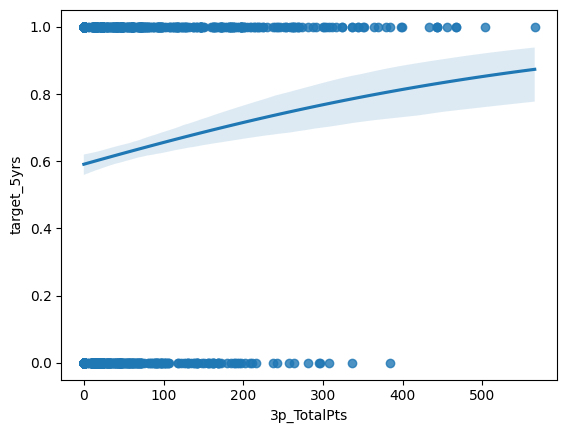

In [13]:
sns.regplot(
    data = nba_feat,
    x = '3p_TotalPts',
    y = 'target_5yrs',
    logistic= True
)

In [16]:
nba_feat.sort_values(by='PointEff',ascending=False)

,gp,min,pts,3pa,3p_made,target_5yrs,TotalPoints,3p_TotalAtmp,3p_TotalPts,PointEff
1265,49,6.5,4.8,2.0,0.8,0,235.2,98.0,117.6,73.846
352,82,38.3,28.2,0.6,0.1,1,2312.4,49.2,24.6,73.629
97,63,11.6,8.2,0.1,0.0,1,516.6,6.3,0.0,70.690
489,35,4.2,2.9,0.3,0.0,0,101.5,10.5,0.0,69.048
118,82,36.6,24.3,0.0,0.0,1,1992.6,0.0,0.0,66.393
...,...,...,...,...,...,...,...,...,...,...
267,44,7.6,1.1,0.0,0.0,0,48.4,0.0,0.0,14.474
178,21,4.9,0.7,0.0,0.0,0,14.7,0.0,0.0,14.286
805,70,9.9,1.3,0.1,0.0,1,91.0,7.0,0.0,13.131
693,18,7.9,1.0,0.0,0.0,1,18.0,0.0,0.0,12.658
